In [ ]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [ ]:
dfheart = pd.read_csv(r"D:\Imarticus\ml\excel files\HeartDisease.csv")

In [7]:
dfheart

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [8]:
dfheart.shape

(303, 14)

### NaN

In [9]:
dfheart.head()

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [10]:
dfheart.isna().sum()

age                    0
gender                 0
chest_pain             0
rest_bps               0
cholestrol             0
fasting_blood_sugar    0
rest_ecg               0
thalach                0
exer_angina            0
old_peak               0
slope                  0
ca                     0
thalassemia            0
target                 0
dtype: int64

### Error Detection

In [11]:
dfheart.head()

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<Axes: >

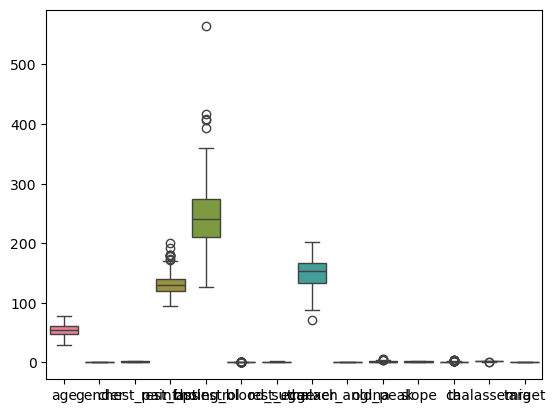

In [12]:
sns.boxplot(dfheart)

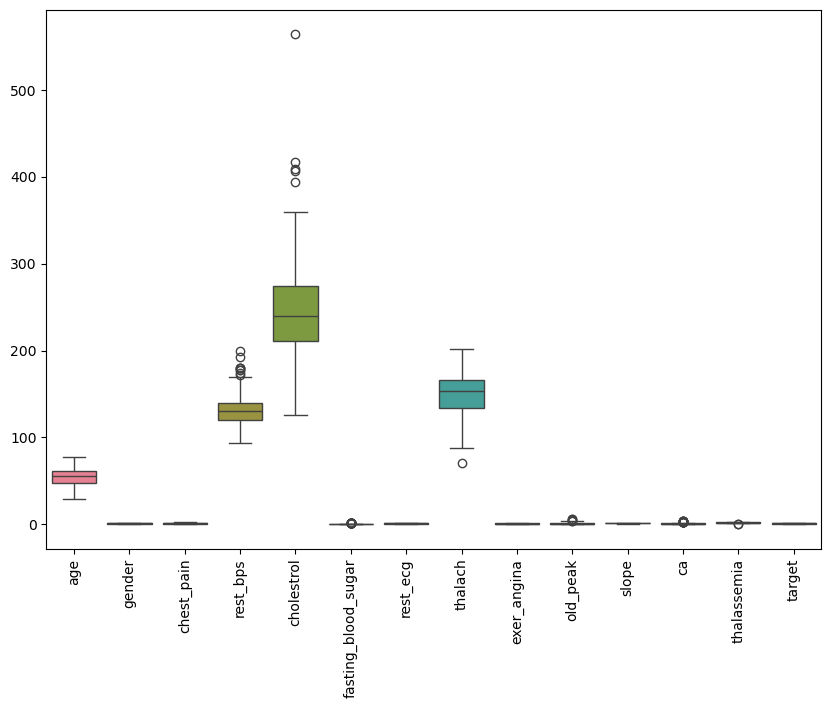

In [17]:
plt.figure(figsize=(10, 7))
sns.boxplot(dfheart)
plt.xticks(rotation = 90)
plt.show()

In [18]:
dfheart.columns

Index(['age', 'gender', 'chest_pain', 'rest_bps', 'cholestrol',
       'fasting_blood_sugar', 'rest_ecg', 'thalach', 'exer_angina', 'old_peak',
       'slope', 'ca', 'thalassemia', 'target'],
      dtype='object')

In [19]:
cols = [ 'rest_bps', 'cholestrol', 'fasting_blood_sugar',  'thalach',  'old_peak', 'ca', 'thalassemia']

In [20]:
import time

In [21]:
for c in cols : 
    print(c)
    time.sleep(1)

rest_bps
cholestrol
fasting_blood_sugar
thalach
old_peak
ca
thalassemia


In [22]:
for c in cols : 
    print(dfheart[c])
    time.sleep(1)
    print()

0      145
1      130
2      130
3      120
4      120
      ... 
298    140
299    110
300    144
301    130
302    130
Name: rest_bps, Length: 303, dtype: int64

0      233
1      250
2      204
3      236
4      354
      ... 
298    241
299    264
300    193
301    131
302    236
Name: cholestrol, Length: 303, dtype: int64

0      1
1      0
2      0
3      0
4      0
      ..
298    0
299    0
300    1
301    0
302    0
Name: fasting_blood_sugar, Length: 303, dtype: int64

0      150
1      187
2      172
3      178
4      163
      ... 
298    123
299    132
300    141
301    115
302    174
Name: thalach, Length: 303, dtype: int64

0      2.3
1      3.5
2      1.4
3      0.8
4      0.6
      ... 
298    0.2
299    1.2
300    3.4
301    1.2
302    0.0
Name: old_peak, Length: 303, dtype: float64

0      0
1      0
2      0
3      0
4      0
      ..
298    0
299    0
300    2
301    1
302    1
Name: ca, Length: 303, dtype: int64

0      1
1      2
2      2
3      2
4      2
      .

In [23]:
for c in cols : 
    q1 = dfheart[c].quantile(0.25)
    q3 = dfheart[c].quantile(0.75)
    iqr = q3 - q1
    lowerlimit = q1 - (1.5 * iqr)
    upperlimit = q3 + (1.5 * iqr)
    dfheart[c] = dfheart[c].map(lambda x : lowerlimit if x < lowerlimit else upperlimit if x > upperlimit else x)

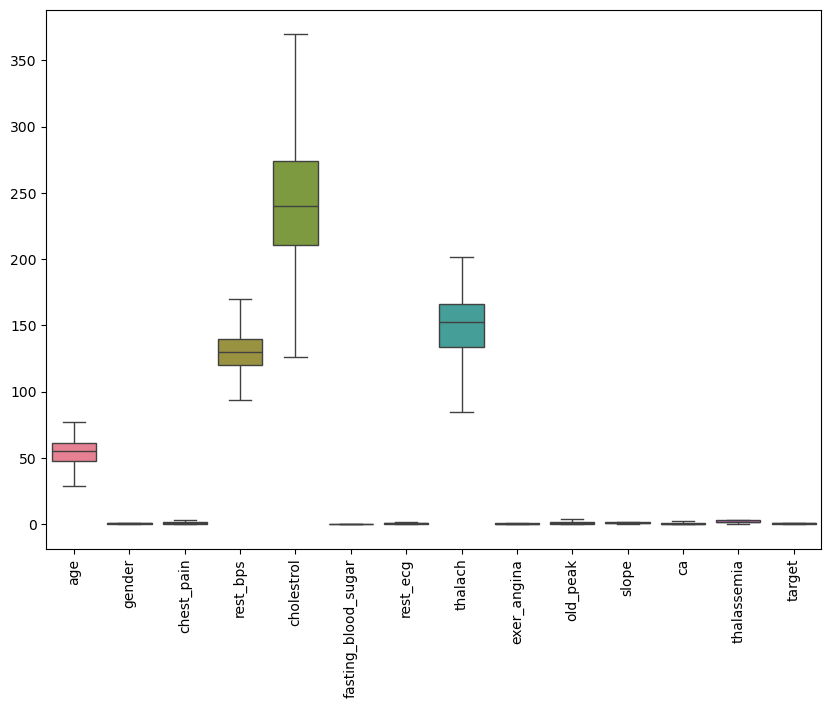

In [24]:
plt.figure(figsize=(10, 7))
sns.boxplot(dfheart)
plt.xticks(rotation = 90)
plt.show()

### Encoding

In [25]:
dfheart.head()

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia,target
0,63,1,3,145.0,233.0,0.0,0,150.0,0,2.3,0,0.0,1.0,1
1,37,1,2,130.0,250.0,0.0,1,187.0,0,3.5,0,0.0,2.0,1
2,41,0,1,130.0,204.0,0.0,0,172.0,0,1.4,2,0.0,2.0,1
3,56,1,1,120.0,236.0,0.0,1,178.0,0,0.8,2,0.0,2.0,1
4,57,0,0,120.0,354.0,0.0,1,163.0,1,0.6,2,0.0,2.0,1


In [26]:
dfheart.dtypes

age                      int64
gender                   int64
chest_pain               int64
rest_bps               float64
cholestrol             float64
fasting_blood_sugar    float64
rest_ecg                 int64
thalach                float64
exer_angina              int64
old_peak               float64
slope                    int64
ca                     float64
thalassemia            float64
target                   int64
dtype: object

### Data Separation

In [27]:
dfheart.head()

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia,target
0,63,1,3,145.0,233.0,0.0,0,150.0,0,2.3,0,0.0,1.0,1
1,37,1,2,130.0,250.0,0.0,1,187.0,0,3.5,0,0.0,2.0,1
2,41,0,1,130.0,204.0,0.0,0,172.0,0,1.4,2,0.0,2.0,1
3,56,1,1,120.0,236.0,0.0,1,178.0,0,0.8,2,0.0,2.0,1
4,57,0,0,120.0,354.0,0.0,1,163.0,1,0.6,2,0.0,2.0,1


In [28]:
dfheart.drop("target", axis = 1)

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia
0,63,1,3,145.0,233.0,0.0,0,150.0,0,2.3,0,0.0,1.0
1,37,1,2,130.0,250.0,0.0,1,187.0,0,3.5,0,0.0,2.0
2,41,0,1,130.0,204.0,0.0,0,172.0,0,1.4,2,0.0,2.0
3,56,1,1,120.0,236.0,0.0,1,178.0,0,0.8,2,0.0,2.0
4,57,0,0,120.0,354.0,0.0,1,163.0,1,0.6,2,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140.0,241.0,0.0,1,123.0,1,0.2,1,0.0,3.0
299,45,1,3,110.0,264.0,0.0,1,132.0,0,1.2,1,0.0,3.0
300,68,1,0,144.0,193.0,0.0,1,141.0,0,3.4,1,2.0,3.0
301,57,1,0,130.0,131.0,0.0,1,115.0,1,1.2,1,1.0,3.0


In [29]:
X = dfheart.drop("target", axis = 1)

In [30]:
X

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia
0,63,1,3,145.0,233.0,0.0,0,150.0,0,2.3,0,0.0,1.0
1,37,1,2,130.0,250.0,0.0,1,187.0,0,3.5,0,0.0,2.0
2,41,0,1,130.0,204.0,0.0,0,172.0,0,1.4,2,0.0,2.0
3,56,1,1,120.0,236.0,0.0,1,178.0,0,0.8,2,0.0,2.0
4,57,0,0,120.0,354.0,0.0,1,163.0,1,0.6,2,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140.0,241.0,0.0,1,123.0,1,0.2,1,0.0,3.0
299,45,1,3,110.0,264.0,0.0,1,132.0,0,1.2,1,0.0,3.0
300,68,1,0,144.0,193.0,0.0,1,141.0,0,3.4,1,2.0,3.0
301,57,1,0,130.0,131.0,0.0,1,115.0,1,1.2,1,1.0,3.0


In [31]:
y = dfheart["target"]

In [32]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

### imbalance

In [33]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [34]:
y.value_counts()

target
1    165
0    138
Name: count, dtype: int64

<Axes: xlabel='target'>

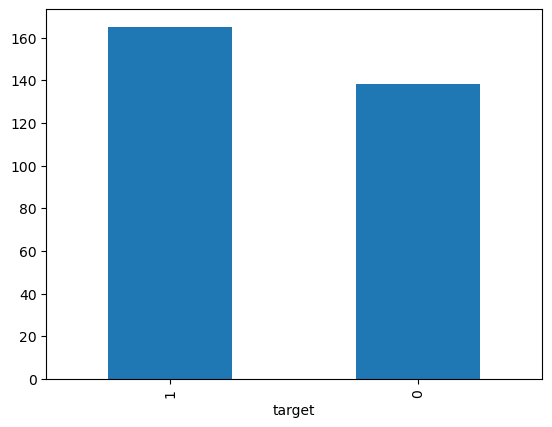

In [35]:
y.value_counts().plot(kind = "bar")

In [36]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [37]:
from imblearn.over_sampling import RandomOverSampler

In [38]:
ros = RandomOverSampler()

In [39]:
ros

RandomOverSampler()

In [40]:
X_ros, y_ros = ros.fit_resample(X, y)

In [41]:
X.shape

(303, 13)

In [42]:
X_ros.shape

(330, 13)

In [43]:
y.value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [44]:
y_ros.value_counts()

target
1    165
0    165
Name: count, dtype: int64

<Axes: xlabel='target'>

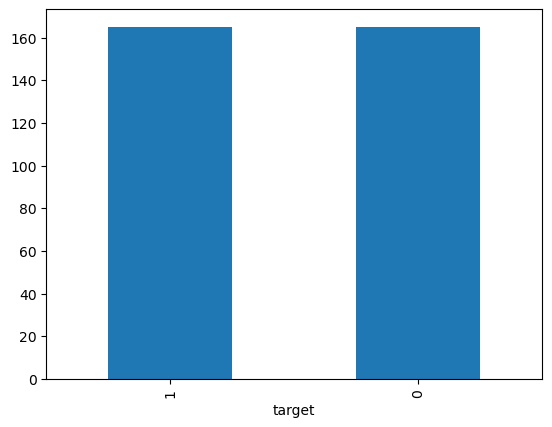

In [45]:
y_ros.value_counts().plot(kind = "bar")

### Data Splitting

In [46]:
from sklearn.model_selection import train_test_split

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X_ros, y_ros, test_size= 0.20, random_state= 2)

In [94]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, random_state= 2)

In [95]:
X_train.shape

(264, 13)

In [96]:
X_test.shape

(66, 13)

In [97]:
X_ros.shape

(330, 13)

In [98]:
y_ros.shape

(330,)

In [99]:
y_train.shape

(264,)

In [100]:
y_test.shape

(66,)

### Model Building

In [101]:
from sklearn.tree import DecisionTreeClassifier

In [102]:
dt_model = DecisionTreeClassifier()

In [103]:
dt_model

DecisionTreeClassifier()

In [104]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [105]:
dt_model.score(X_train, y_train)

1.0

In [106]:
dt_model.score(X_test, y_test)

0.803030303030303

In [107]:
scorelist = []
for i in range(1,1000):
    Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.20, random_state= i)
    dt = DecisionTreeClassifier()
    dt.fit(Xtrain, ytrain)
    sc = dt.score(Xtest, ytest)
    scorelist.append(sc)

m = max(scorelist)
rs = scorelist.index(m)
print("Random State", rs)
print("Max Score", m)

Random State 322
Max Score 0.9016393442622951
